# 5. Balanced the train dataset

In [1]:
import pandas as pd
from sklearn.utils import resample
import os

In [2]:
# CONSTANTs
CIRCUIT_LIST = [
    "simple_circuit",
    "montreal_circuit",
    "montmelo_circuit",
    "nurburgring_circuit"
]
COUNTER_BASE_DIR = ""
CLOCK_BASE_DIR = ""
BASE_DIR = CLOCK_BASE_DIR #COUNTER_BASE_DIR
CSV_FILE_NAME = 'train.csv'

In [3]:
# Step 3: Categorize angular velocity (w) into 5 categories
# def categorize_w(w):
#     if w < -1.0:
#         return "sharp_right"
#     elif w < -0.1:
#         return "right"
#     elif w <= 0.1:
#         return "straight"
#     elif w <= 1.0:
#         return "left"
#     else:
#         return "sharp_left"

# def categorize_w(w):
#     if w < -1.0:
#         return "sharp_right"
#     elif w < -0.09:
#         return "right"
#     elif w <= 0.09:
#         return "straight"
#     elif w <= 1.0:
#         return "left"
#     else:
#         return "sharp_left"

def categorize_w(w):
    if w < -1.0:
        return "sharp_right"
    elif w < -0.05:
        return "right"
    elif w <= 0.05:
        return "straight"
    elif w <= 1.0:
        return "left"
    else:
        return "sharp_left"

In [4]:
# df = pd.read_csv(os.path.join(BASE_DIR,'simple_circuit',CSV_FILE_NAME))
# df['w_category'] = df['w'].apply(categorize_w2)
# df['w_category'].count()

In [5]:
TARGET_COUNT = 5000
VERSION = 'v3.2';

for circuit in CIRCUIT_LIST:
    balanced_classes = []
    # loading dataset
    df = pd.read_csv(os.path.join(BASE_DIR,circuit,CSV_FILE_NAME))
    
    df['w_category'] = df['w'].apply(categorize_w)

    # Process each class
    for category in df['w_category'].unique():
        class_df = df[df['w_category'] == category]
    
        if len(class_df) > TARGET_COUNT:
            # Downsample
            class_balanced = class_df.sample(n=TARGET_COUNT, random_state=42)
        else:
            # Oversample with replacement
            class_balanced = resample(class_df, replace=True, n_samples=TARGET_COUNT, random_state=42)
    
        balanced_classes.append(class_balanced)

    
    # Combine all balanced classes
    df_balanced = pd.concat(balanced_classes).sample(frac=1, random_state=42).reset_index(drop=True)

    df_balanced.to_csv(os.path.join(BASE_DIR,circuit,f'balanced_train_{VERSION}.csv'),index=False)

## Single dataset

In [12]:
TARGET_COUNT = 5000
VERSION = 'v2';
balanced_classes = []

# loading dataset
df = pd.read_csv(os.path.join(BASE_DIR,'montreal_circuit',CSV_FILE_NAME))

df['w_category'] = df['w'].apply(categorize_w)

# Process each class
for category in df['w_category'].unique():
    class_df = df[df['w_category'] == category]

    if len(class_df) > TARGET_COUNT:
        # Downsample
        if category == 'straight':
            class_balanced = class_df.sample(n=4000, random_state=42)
        else: class_balanced = class_df.sample(n=TARGET_COUNT, random_state=42)
    else:
        # Oversample with replacement
        class_balanced = resample(class_df, replace=True, n_samples=TARGET_COUNT, random_state=42)

    balanced_classes.append(class_balanced)


# Combine all balanced classes
df_balanced = pd.concat(balanced_classes).sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced.to_csv(os.path.join(BASE_DIR,'montreal_circuit',f'balanced_train_{VERSION}.csv'),index=False)

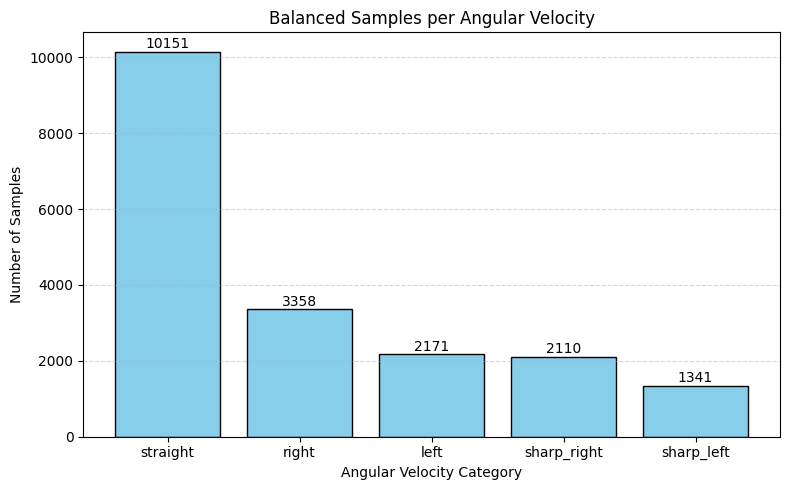

In [19]:
category_counts = balanced_df['w_category'].value_counts()

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')

# Add counts above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)

# Labels and title
plt.title(f"Balanced Samples per Angular Velocity")
plt.xlabel("Angular Velocity Category")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/home/codezerro/Desktop/models_v2/balanced_dataset.png')
plt.show()